# Лабораторная работа 8

Тема: **Свёрточные нейросети (CNN) для CIFAR‑10 в PyTorch**  
Цель: построить и исследовать собственную свёрточную сеть для классификации изображений CIFAR‑10, понять, как архитектура и гиперпараметры влияют на качество.

> Этот ноутбук специально оформлен как практическое задание.  
> Код даёт каркас, но **основные баллы** ставятся за ваши эксперименты и ваши тексты.  
> Если вы просто скормите ноутбук генеративной модели и вставите сгенерированные ответы, это будет видно по стилю и несоответствию коду/графикам.


## 1. Ваши ожидания от CNN

Перед началом работы поставьте скачиваться CIFAR‑10 и зафиксируйте своё понимание:

1. Чем, с вашей точки зрения, свёрточная сеть отличается от "обычного" MLP, если объяснять без формул, на интуитивном уровне.  
2. Почему для картинок обычно используют CNN, а не только полносвязные слои.  
3. Какую примерно точность на CIFAR‑10 вы считаете "разумной" для простой самодельной CNN (не топовой).

Пишите 6–10 предложений, на нормальном языке, как если бы объясняли одногруппнику.


In [1]:
intro_text = """
1) CNN учитывает расположение пикселей на изображении. 
Он анализирует участки изображения и ищет признаки, например, края, формы объектов и текстуры. 
А MLP получает картинку как набор чисел.
2) Картинки имеют пространственную структуру: соседние пиксели связаны.
MLP не использует это, он обрабатывает каждый пиксель изолированно.
3) Для простой самодельной CNN я бы ожидала точность примерно 60-70%
"""
print(intro_text)


1) CNN учитывает расположение пикселей на изображении. 
Он анализирует участки изображения и ищет признаки, например, края, формы объектов и текстуры. 
А MLP получает картинку как набор чисел.
2) Картинки имеют пространственную структуру: соседние пиксели связаны.
MLP не использует это, он обрабатывает каждый пиксель изолированно.
3) Для простой самодельной CNN я бы ожидала точность примерно 60-70%



## 2. Импорт библиотек и настройка среды

Сделаем стандартные шаги:
- импорт PyTorch и torchvision;
- настройка отрисовки графиков;
- фиксация seed (выберите число сами);
- определение устройства (`cpu` или `cuda`).


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Ваш личный seed (заполните его)
MY_SEED = 11
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 11


## 3. CIFAR‑10: загрузка, нормализация, первичный просмотр

Загрузим CIFAR‑10 через `torchvision.datasets.CIFAR10`.

Сделаем:
- перевод в тензор (`ToTensor`);
- нормализацию по каналам (можно использовать стандартные значения для CIFAR‑10);
- DataLoader для train и test.


In [3]:
batch_size = 128  # при выполнении работы попробуйте хотя бы ещё одно значение
# При 64 - обучение медленнее (больше шагов), кривые чуть шумнее.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

classes = train_dataset.classes
print("Классы CIFAR‑10:", classes)
print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("batch_size =", batch_size)

Классы CIFAR‑10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Размер train: 50000
Размер test : 10000
batch_size = 128


Посмотрим на несколько изображений, чтобы глазами увидеть разнообразие классов и качество картинок.


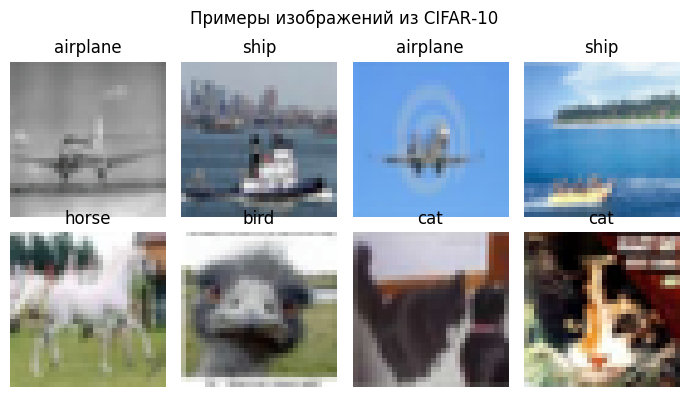

In [4]:
images, labels = next(iter(train_loader))

def denorm(img_tensor):
    # разворачиваем нормализацию для отображения
    img = img_tensor.permute(1, 2, 0).numpy()
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = img * std + mean
    return np.clip(img, 0, 1)

plt.figure(figsize=(7, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(denorm(images[i]))
    plt.title(classes[labels[i].item()])
    plt.axis("off")
plt.suptitle("Примеры изображений из CIFAR‑10")
plt.tight_layout()
plt.show()

### Краткий комментарий по данным (заполняется студентом)

Опишите в 3–5 предложениях:
- какие классы по картинкам вам кажутся наиболее сложными для различения;
- есть ли визуальный шум/размытость;
- насколько задача кажется вам сложнее/проще, чем MNIST.


In [5]:
data_comment = """
Самыми сложными для различения мне кажутся классы cat и horse, 
потому что изображения всего 32×32 пикселя, поэтому многие детали плохо различимы. 
Некоторые объекты можно узнать только по общей форме или цвету.

По сравнению с MNIST эта задача кажется значительно сложнее. В MNIST были чёткие чёрно-белые цифры, 
а здесь цветные фотографии реальных объектов с разными ракурсами и фоном.
"""
print(data_comment)


Самыми сложными для различения мне кажутся классы cat и horse, 
потому что изображения всего 32×32 пикселя, поэтому многие детали плохо различимы. 
Некоторые объекты можно узнать только по общей форме или цвету.

По сравнению с MNIST эта задача кажется значительно сложнее. В MNIST были чёткие чёрно-белые цифры, 
а здесь цветные фотографии реальных объектов с разными ракурсами и фоном.



## 4. Архитектура CNN (исходный вариант)

В этой лабораторной важно не просто запустить готовый код, а **понимать** свою архитектуру и уметь её менять.

Задайте базовый вариант сети:
- несколько блоков `Conv2d → ReLU → MaxPool2d`;
- один или два полносвязных слоя после свёрток;
- выходной слой с 10 логитами.

Ниже — пример архитектуры. В своей работе вы **обязаны** попробовать хотя бы ещё один вариант (с другим числом каналов/слоёв) и сравнить результаты.


In [6]:
class SimpleCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCIFARCNN(num_classes=len(classes)).to(device)
print(model)

SimpleCIFARCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


### Ваш комментарий к архитектуре

Ответьте коротко:
- почему вы считаете, что такого размера/глубины сети **должно** быть примерно достаточно для CIFAR‑10 (или, наоборот, нет);
- какие альтернативы вы планируете попробовать (например, другой размер фильтров, дополнительные свёрточные слои, Dropout).


In [7]:
arch_comment = """
Трёх свёрточных блоков (32->64->128 каналов) должно хватить для CIFAR-10. 
Сеть сможет сначала находить простые признаки (границы, цвета), а затем более сложные формы объектов.

Хочу проверить BatchNorm и Dropout, чтобы посмотреть, помогут ли они улучшить качество и уменьшить переобучение. 
Можно попробовать увеличить число каналов до 64->128->256 и сравнить результат с базовой моделью.
"""
print(arch_comment)



Трёх свёрточных блоков (32->64->128 каналов) должно хватить для CIFAR-10. 
Сеть сможет сначала находить простые признаки (границы, цвета), а затем более сложные формы объектов.

Хочу проверить BatchNorm и Dropout, чтобы посмотреть, помогут ли они улучшить качество и уменьшить переобучение. 
Можно попробовать увеличить число каналов до 64->128->256 и сравнить результат с базовой моделью.



## 5. Функция потерь, оптимизатор и общий цикл обучения

Используем:
- `CrossEntropyLoss` для многоклассовой классификации;
- один из оптимизаторов (`SGD`, `Adam` и т.п.) с выбранным `learning_rate`.

В ходе работы вы должны попробовать хотя бы одну альтернативную настройку (другой `lr` и/или другой оптимизатор) и сравнить с базовой.


In [8]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001


In [9]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Обучение базовой модели

Запустим обучение на несколько эпох, сохраняя историю loss/accuracy.

Рекомендуется:
- начать с небольшого числа эпох (например, 5–8);
- затем увеличить и посмотреть, появляется ли переобучение.


In [10]:
num_epochs = 15  # попробуйте изменить и сравнить результаты

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

Эпоха 1/15: train_loss=1.3901, train_acc=0.4956, test_loss=1.0950, test_acc=0.6125
Эпоха 2/15: train_loss=0.9519, train_acc=0.6635, test_loss=0.8739, test_acc=0.6942
Эпоха 3/15: train_loss=0.7677, train_acc=0.7299, test_loss=0.7826, test_acc=0.7245
Эпоха 4/15: train_loss=0.6424, train_acc=0.7747, test_loss=0.7515, test_acc=0.7435
Эпоха 5/15: train_loss=0.5365, train_acc=0.8135, test_loss=0.7527, test_acc=0.7482
Эпоха 6/15: train_loss=0.4547, train_acc=0.8412, test_loss=0.7929, test_acc=0.7388
Эпоха 7/15: train_loss=0.3716, train_acc=0.8700, test_loss=0.7557, test_acc=0.7577
Эпоха 8/15: train_loss=0.2870, train_acc=0.9002, test_loss=0.8098, test_acc=0.7569
Эпоха 9/15: train_loss=0.2151, train_acc=0.9248, test_loss=0.8645, test_acc=0.7604
Эпоха 10/15: train_loss=0.1688, train_acc=0.9414, test_loss=0.9372, test_acc=0.7641
Эпоха 11/15: train_loss=0.1326, train_acc=0.9528, test_loss=1.1029, test_acc=0.7515
Эпоха 12/15: train_loss=0.1025, train_acc=0.9646, test_loss=1.2167, test_acc=0.7528
Э

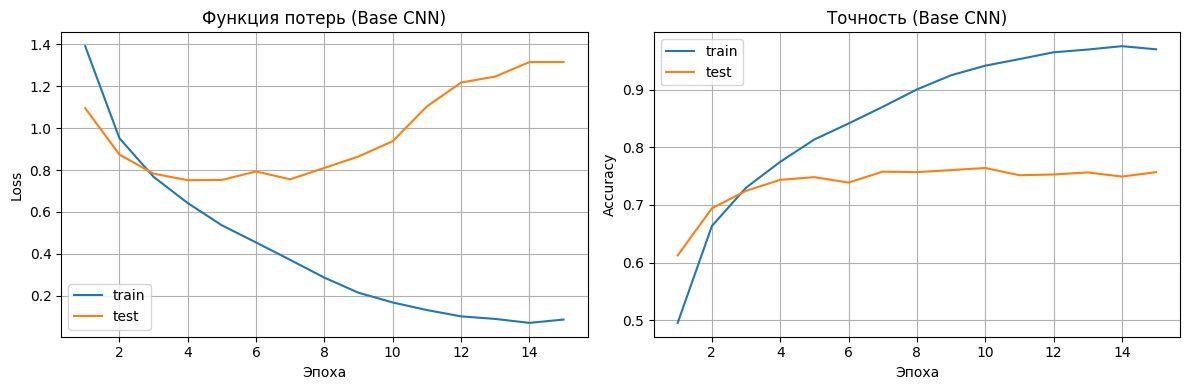

Финальная точность: train=0.9698, test=0.7568


In [11]:
def plot_history(history, title="CNN"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train")
    plt.plot(epochs, history["test_loss"], label="test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(f"Функция потерь ({title})")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train")
    plt.plot(epochs, history["test_acc"], label="test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(f"Точность ({title})")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(
        f"Финальная точность: "
        f"train={history['train_acc'][-1]:.4f}, "
        f"test={history['test_acc'][-1]:.4f}"
    )
plot_history(history, "Base CNN")

### Анализ кривых обучения (заполняется студентом)

Опишите в 6–8 предложениях:
- как ведут себя train/test loss (сходятся ли, расходятся ли);
- есть ли заметный разрыв между train и test accuracy;
- кажется ли вам, что модель уже переобучилась или ещё недообучена;
- какие изменения (архитектуры, lr, числа эпох) вы бы попробовали дальше.


In [18]:
training_analysis = """
1) В начале модель обучалась довольно быстро: test accuracy выросла с 0.6125 на 1 эпохе до 0.7482 на 5. 
Лучший результат по test_acc был на 10 эпохе - 0.7641.

2) К концу обучения появился большой разрыв между train и test accuracy:
train_acc=0.9698 против test_acc=0.7568.

3) Видно переобучение. После 10 эпохи train loss продолжал снижаться
(с 0.1688 до 0.0873), а test loss наоборот вырос с 0.9372 до 1.3148.
При этом test accuracy почти перестала улучшаться и колебалась около 0.75–0.76.

4) Если бы я продолжала эксперименты, то попробовала бы уменьшить число эпох примерно до 8–10,
добавить Dropout или другую регуляризацию, а также подобрать другой learning rate.
Судя по графикам, это могло бы уменьшить переобучение и улучшить качество на тестовой выборке.
"""
print(training_analysis)


1) В начале модель обучалась довольно быстро: test accuracy выросла с 0.6125 на 1 эпохе до 0.7482 на 5. 
Лучший результат по test_acc был на 10 эпохе - 0.7641.

2) К концу обучения появился большой разрыв между train и test accuracy:
train_acc=0.9698 против test_acc=0.7568.

3) Видно переобучение. После 10 эпохи train loss продолжал снижаться
(с 0.1688 до 0.0873), а test loss наоборот вырос с 0.9372 до 1.3148.
При этом test accuracy почти перестала улучшаться и колебалась около 0.75–0.76.

4) Если бы я продолжала эксперименты, то попробовала бы уменьшить число эпох примерно до 8–10,
добавить Dropout или другую регуляризацию, а также подобрать другой learning rate.
Судя по графикам, это могло бы уменьшить переобучение и улучшить качество на тестовой выборке.



## 7. Примеры правильных и неправильных предсказаний

Посмотрим на несколько изображений, которые модель классифицирует верно и неверно, чтобы понять, где ей сложнее всего.


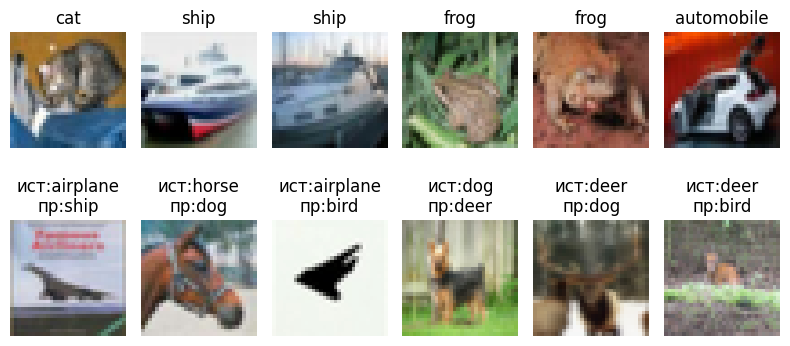

In [13]:
model.eval()
correct_imgs, correct_true, correct_pred = [], [], []
wrong_imgs, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for img, lab, pr in zip(images, labels, preds):
            if lab == pr and len(correct_imgs) < 6:
                correct_imgs.append(img.cpu())
                correct_true.append(lab.cpu().item())
                correct_pred.append(pr.cpu().item())
            if lab != pr and len(wrong_imgs) < 6:
                wrong_imgs.append(img.cpu())
                wrong_true.append(lab.cpu().item())
                wrong_pred.append(pr.cpu().item())
        if len(correct_imgs) >= 6 and len(wrong_imgs) >= 6:
            break

plt.figure(figsize=(8, 4))
for i in range(len(correct_imgs)):
    plt.subplot(2, 6, i + 1)
    plt.imshow(denorm(correct_imgs[i]))
    plt.title(classes[correct_true[i]])
    plt.axis("off")
for i in range(len(wrong_imgs)):
    plt.subplot(2, 6, 6 + i + 1)
    plt.imshow(denorm(wrong_imgs[i]))
    true_label = classes[wrong_true[i]]
    pred_label = classes[wrong_pred[i]]
    plt.title(f"ист:{true_label}\nпр:{pred_label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Комментарий по ошибкам

Ответьте кратко:
- какие пары классов чаще всего путаются в ваших примерах;
- выглядят ли эти ошибки "человечески понятными" или, наоборот, странными;
- есть ли примеры, где вы сами сомневались бы в правильном классе.


In [14]:
errors_comment = """Чаще всего модель путает похожие классы животных: dog, deer и airplane. 
Большинство ошибок выглядят вполне логично, потому что изображения маленькие и размытые. 
Например самолёт на одном из примеров похож на силуэт птицы. Мне самой тут что-то трудно различить.
"""
print(errors_comment)


Чаще всего модель путает похожие классы животных: dog, deer и airplane. 
Большинство ошибок выглядят вполне логично, потому что изображения маленькие и размытые. 
Например самолёт на одном из примеров похож на силуэт птицы. Мне самой тут что-то трудно различить.



## 8. Эксперименты по улучшению модели

В **самостоятельной** части лабораторной вы должны будете:
- изменить архитектуру (добавить/убрать слой, поменять число каналов, добавить Dropout/BatchNorm);
- изменить настройки обучения (другой оптимизатор, lr, число эпох);
- сравнить **минимум два** варианта модели по test accuracy и кривым обучения.

Здесь не приводится готовый код, чтобы не превращать задание в копирование. Используйте функции и блоки выше как строительные кирпичики.


In [15]:
# МОДЕЛЬ 2: те же каналы, но добавляем BatchNorm и Dropout
class ImprovedCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),   # нормализует после свёртки
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.2),            # p=0.2 - лучший по ЛР 5
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# МОДЕЛЬ 3: каналы 64->128->256 + BatchNorm + Dropout p=0.2
class WiderCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.2),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Запускаем Модель 2
torch.manual_seed(MY_SEED)
model2 = ImprovedCIFARCNN(num_classes=len(classes)).to(device)
optimizer2 = torch.optim.AdamW(model2.parameters(), lr=1e-3, weight_decay=1e-4)
history2 = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

print(f"Модель 2: {sum(p.numel() for p in model2.parameters()):,}")
print("-" * 70)
for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model2, train_loader, optimizer2, criterion, device)
    test_loss,  test_acc  = evaluate(model2, test_loader, criterion, device)
    history2["train_loss"].append(train_loss)
    history2["train_acc"].append(train_acc)
    history2["test_loss"].append(test_loss)
    history2["test_acc"].append(test_acc)
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Эпоха {epoch:2d}/{num_epochs} | train={train_acc:.4f}, test={test_acc:.4f}")
print(f"  Итог: test_acc = {history2['test_acc'][-1]:.4f}")


# Запускаем Модель 3
torch.manual_seed(MY_SEED)
model3 = WiderCIFARCNN(num_classes=len(classes)).to(device)
optimizer3 = torch.optim.AdamW(model3.parameters(), lr=1e-3, weight_decay=1e-4)
history3 = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

print(f"\nМодель 3: {sum(p.numel() for p in model3.parameters()):,}")
print("-" * 70)
for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model3, train_loader, optimizer3, criterion, device)
    test_loss,  test_acc  = evaluate(model3, test_loader, criterion, device)
    history3["train_loss"].append(train_loss)
    history3["train_acc"].append(train_acc)
    history3["test_loss"].append(test_loss)
    history3["test_acc"].append(test_acc)
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Эпоха {epoch:2d}/{num_epochs} | train={train_acc:.4f}, test={test_acc:.4f}")
print(f"  Итог: test_acc = {history3['test_acc'][-1]:.4f}")


Модель 2: 620,810
----------------------------------------------------------------------
  Эпоха  1/15 | train=0.5389, test=0.6384
  Эпоха  5/15 | train=0.7680, test=0.7384
  Эпоха 10/15 | train=0.8401, test=0.7900
  Эпоха 15/15 | train=0.8820, test=0.8028
  Итог: test_acc = 0.8028

Модель 3: 2,474,506
----------------------------------------------------------------------
  Эпоха  1/15 | train=0.4998, test=0.5852
  Эпоха  5/15 | train=0.7895, test=0.7845
  Эпоха 10/15 | train=0.8803, test=0.8144
  Эпоха 15/15 | train=0.9334, test=0.8018
  Итог: test_acc = 0.8018


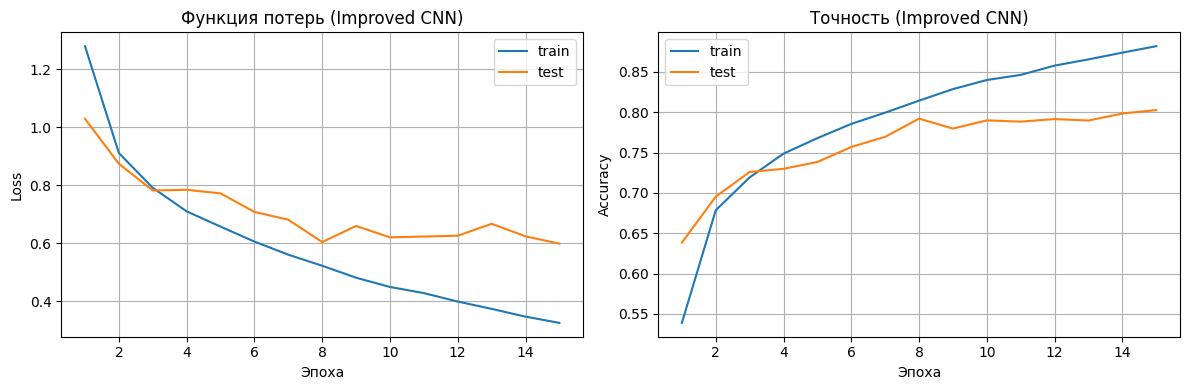

Финальная точность: train=0.8820, test=0.8028


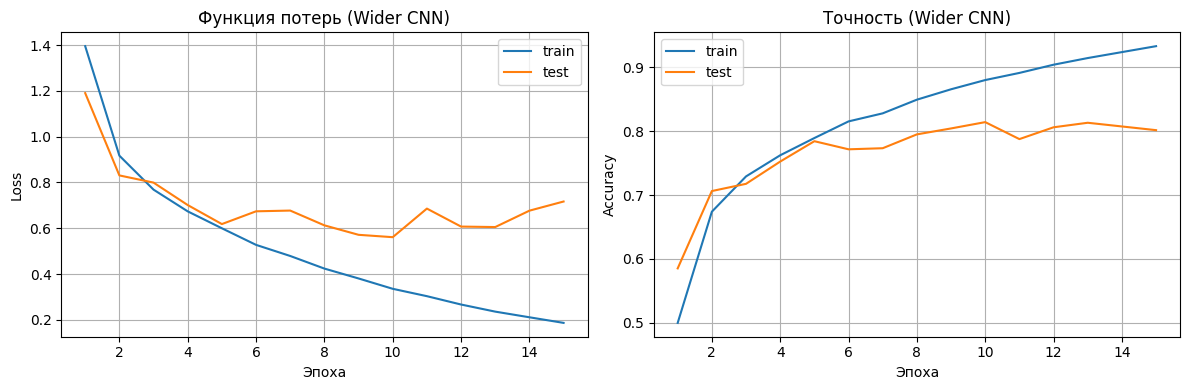

Финальная точность: train=0.9334, test=0.8018


In [16]:
plot_history(history2, "Improved CNN")
plot_history(history3, "Wider CNN")

## 9. Итоговые выводы по лабораторной

В конце опишите:
- до какой тестовой точности вы дошли для разных вариантов моделей и при каких настройках;
- какие изменения архитектуры/гиперпараметров дали наибольший эффект;
- что для вас стало главным практическим выводом о работе CNN на CIFAR‑10 (например, чувствительность к lr, важность аугментаций, глубина сети и т.п.).

Пишите 10–15 предложений, ссылаясь на **свои** эксперименты, а не на теорию из интернета.


In [17]:
final_summary = """
1) Базовая CNN (3 свёрточных блока 32->64->128, Adam, 15 эпох) показала test_acc=0.7568. 
После этого я попробовала добавить BatchNorm и Dropout(p=0.2). 
Такая модель достигла test_acc=0.8028 и стала лучшим вариантом среди моих экспериментов. Также я проверила более широкую сеть с каналами 64->128->256, BatchNorm и Dropout. 
Несмотря на увеличение числа параметров до 2 474 506, итоговая test accuracy составила 0.8018, то есть практически не улучшилась по сравнению с моделью 2.

2) Самый заметный эффект дали BatchNorm и Dropout. После их добавления test accuracy выросла с 0.7568 до 0.8028. 
Получается, что в моих экспериментах регуляризация и стабилизация обучения оказались полезнее, чем увеличение числа параметров.

3) По моим результатам глубина сети сама по себе не гарантирует улучшение качества. Намного важнее правильно настроить обучение и использовать BatchNorm и Dropout. 
Также стало видно, что базовая модель быстро начала переобучаться: train_acc вырос до 0.9698, а test_acc остановился около 0.76. После добавления регуляризации качество на тесте стало выше и стабильнее. Если бы я решала похожую задачу ещё раз, то начала бы с архитектуры уровня модели 2: BatchNorm, Dropout=0.2 и AdamW с lr=1e-3, а уже потом пробовала более крупные сети.
"""
print(final_summary)

ЗДЕСЬ НАПИШИТЕ ИТОГОВЫЙ ТЕКСТ ПО ЛАБОРАТОРНОЙ.
Упомяните конкретные цифры (test accuracy для разных моделей),
и сформулируйте свои личные правила: какую CNN и с какими настройками
вы бы стали пробовать первой в новой задаче, похожей на CIFAR‑10.
